# Standard Cost Comparison For All Materials
**4/5/2026 - Project Start**



Looking to update obsolete standard costs w/ a standardized formula (see below).<br>
$$\text{new\_std\_cost} = \text{avg\_cost} \times (1 + markup)$$

History and Context: <br>
> Current standard prices were adjusted on an "as needed" basis by previous owners. <br>
> Adjustments were made per material item row as projects and sales were being priced out. <br>
> On top of this, they also applied global increases based on market "feel". <br>
> This is not very sustainable at all and a "by-feel" basis on top of global increases can cause slow moving items to have obsolete standard pricing while fast moving items may end up inflated. <br>

Initial concept and experiment done w/ a smaller sample (`std_cost_comparison_pvc`). <br>
> Sample experiment showed that 25%, 30%, and 35% markups were all fairly close. <br>

Need to come up w/ a sort of "current" markup to compare these proposed markups to. <br>
Also need to figure if a flat material wide markup is going to be okay or if each material might need their own markup. <br>
The scatter plot from the smaller sample experiment also showed a lot of odd values. Plan to detect and flag these too. <br>

Data source is `std_cost_comparison_materials_data`, containing more fields than the PVC sample (`std_cost_comparison_pvc_data` had trimmed columns).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve

plt.rcParams.update({'figure.facecolor': '#2b2b2b', 'axes.facecolor': '#3a3a3a', 'axes.edgecolor': '#888', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white', 'text.color': 'white', 'grid.color': '#555', 'axes.titlecolor': 'white'})
df = pd.read_excel('std_cost_comparison_materials_data.xlsx')
df.head()

,item_no,item_desc_1,item_desc_2,prod_cat,uom,qty_on_hand,qty_allocated,qty_on_ord,reorder_lvl,ord_up_to_lvl,...,std_cost,usage_ptd,usage_ytd,prior_year_usage,bin_no,activity_cd,ytd cost,prior yr $,on hand $,inv level #$
0,010050060096020,BLACK TRESPA,1/2 X 60 X 96,NaN,EA,1,0,0,0,0,...,367.29000,0,0,0,5612,A,0.0,0.0,232.0,0.0
1,010062572096034,TRESPA TOPLAB T.03.40 SILVER,GRAY 5/8X72X96,NaN,SH,3,0,0,0,0,...,724.00207,0,0,3,CUTTING,A,0.0,1478.4,1478.4,0.0
2,010075072096034,TRESPA TOPLAB PLUS SILVERGRAY,3/4X72X96 COLOR 0340,NaN,SH,0,0,0,0,0,...,1075.26595,0,0,0,4706,A,0.0,0.0,0.0,0.0
3,011006024048010,ABS SHEET NATURAL,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,15.52320,0,0,0,NOBIN,O,0.0,0.0,0.0,0.0
4,011006024048110,ABS SHEET BLACK,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,15.52320,0,0,0,NOBIN,O,0.0,0.0,0.0,0.0


## Cleaning
The full materials list contains non-material "catch all" rows (`A, B, BANK FEES, FREIGHT, FABRICATION, etc.`). <br>
Actual material part #s start w/ a 3 digit code as a classification and never starts w/ a letter (`mat_code`). <br>
<br>
Need to filter out rows where `item_no` does not start w/ a number to remove the "catch all" rows. <br>
Also need to flag and filter out any rows w/ `std_cost` or `avg_cost` that are negatives or zero.

In [2]:
item = df['item_no'].astype(str)
is_material = item.str[0].str.isdigit()
excluded = df[~is_material]
df = df[is_material].copy()
df['mat_code'] = item[is_material].str[:3]

for col in ['avg_cost', 'std_cost', 'last_cost']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['avg_cost_missing'] = ~(df['avg_cost'] > 0)
df['std_cost_missing'] = ~(df['std_cost'] > 0)
df['avg_cost_negative'] = df['avg_cost'] < 0
df['std_cost_negative'] = df['std_cost'] < 0

print(f'Number of Rows w/ "catch all" Part #s = {len(excluded)}')
print(f'Number of Rows w/ Material Part #s = {len(df)}')
print()
print(f'Number of Rows Where Average is 0 = {df["avg_cost_missing"].sum()}')
print(f'Number of Rows Where Standard is 0 = {df["std_cost_missing"].sum()}')
print(f'Number of Rows Where Average is negative = {df["avg_cost_negative"].sum()}')
print(f'Number of Rows Where Standard is negative = {df["std_cost_negative"].sum()}')
print()
print(f'Number of Rows w/ Both Average and Standard = {(~df["avg_cost_missing"] & ~df["std_cost_missing"]).sum()}')

Number of Rows w/ "catch all" Part #s = 67
Number of Rows w/ Material Part #s = 5706

Number of Rows Where Average is 0 = 1218
Number of Rows Where Standard is 0 = 495
Number of Rows Where Average is negative = 0
Number of Rows Where Standard is negative = 0

Number of Rows w/ Both Average and Standard = 4276


## Sorting
Looking to see if each material type should receive its own markup %. <br>
Need to separate and sort each material item row into a material type family (by `mat_code`).<br>
Any families = 1 should be excluded to help reduce number of unique markups and overall bloat. <br>
<br>
If there's too many families it might be too much effort and not really help w/ the "lack of standardization" issue...


In [3]:
df = df[~df['avg_cost_missing'] & ~df['std_cost_missing']].copy()

mat_code_count = df['mat_code'].value_counts()
mat_code_1child = mat_code_count[mat_code_count == 1].index
mat_all = len(df)
mat_code_all = df['mat_code'].nunique()

df = df[~df['mat_code'].isin(mat_code_1child)].copy()
df['material'] = df['mat_code']

print(f"Number of Rows w/ Both Average and Standard = {mat_all}")
print(f"Number of Rows Included = {len(df)}")
print()
print(f"Number of Material Families = {mat_code_all}")
print(f"Number of Material Families Excluded = {len(mat_code_1child)}")
print(f"Number of Material Families Included = {df['material'].nunique()}")


Number of Rows w/ Both Average and Standard = 4276
Number of Rows Included = 4261

Number of Material Families = 176
Number of Material Families Excluded = 15
Number of Material Families Included = 161


## Implied Markup
What markups are currently applied to current standard costs? <br>
Fit log(`std_cost`) on log(`avg_cost`) w/ the extreme 1% of ratios trimmed so a few bad rows don't drag the line.<br>
Slope about equal 1 means standard cost (`std_cost`) is basically proportional to average (`avg_cost`), and the intercept gives a markup under that proportional fit.

In [4]:
valid = df.copy()
valid['ratio'] = valid['std_cost'] / valid['avg_cost']
valid['log_ratio'] = np.log(valid['ratio'])

lo, hi = valid['ratio'].quantile(0.01), valid['ratio'].quantile(0.99)
keep = valid[(valid['ratio'] >= lo) & (valid['ratio'] <= hi)]

b, a = np.polyfit(np.log(keep['avg_cost']), np.log(keep['std_cost']), 1)
resid_sd = (np.log(keep['std_cost']) - (a + b * np.log(keep['avg_cost']))).std()

implied_markup = np.exp(a) - 1
median_markup = valid['ratio'].median() - 1

print(f'Trimmed n = {len(keep)}')
print(f'Slope b = {b:.4f} (~{round(b)}, std_cost is proportional to avg_cost)')
print(f'Markup From Intercept = {implied_markup:.1%} (~{round(implied_markup, 2):.0%})')
print(f'Markup From Median Ratio = {median_markup:.1%} (~{round(median_markup, 2):.0%})')
print(f'Residual Spread = {resid_sd:.3f} in log terms')

Trimmed n = 4175
Slope b = 0.9981 (~1, std_cost is proportional to avg_cost)
Markup From Intercept = 49.3% (~49%)
Markup From Median Ratio = 46.9% (~47%)
Residual Spread = 0.327 in log terms


Two markup estimates are printed: one from the regression intercept and one from the median `std_cost / avg_cost` ratio. <br>
> The median-ratio figure `46.9% (~47%)` is the one carried forward as the implied current markup in the scenarios below.<br>
> `~47%` is the middle of a very very wide distribution. It will be used as a loose "current" markup line for comparison to the other proposed markups. 

## Markup by Materials
Checking median markup per material family. `p25` and `p75` show the cutoffs per material. <br>
A single pooled markup might cause under or over pricing of material families. <br>
<br>
Need to check if the families actually differ enough to matter. <br>
This reason on top of "if there's too many families..." will be used to justify having unique standardized markups per family. <br>
(or if having one flat markup would be fine. Preferably this as there are already 100+ material families...)

In [5]:
by_mat = (valid.groupby('material')['ratio'].agg(n='count', median_ratio='median', p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75)).sort_values('n', ascending=False))
by_mat['median_markup'] = by_mat['median_ratio'] - 1
by_mat.style.format({'median_ratio': '{:.2f}', 'p25': '{:.2f}', 'p75': '{:.2f}', 'median_markup': '{:.0%}'})

,n,median_ratio,p25,p75,median_markup
material,,,,,
241,197,1.89,1.60,2.15,89%
050,169,1.47,1.22,1.58,47%
151,149,1.47,1.35,1.67,47%
041,142,2.02,1.74,2.46,102%
022,132,1.78,1.47,2.16,78%
212,118,1.47,1.17,1.54,47%
441,101,1.47,1.32,1.57,47%
261,97,2.02,1.73,2.49,102%
043,90,1.22,0.68,1.47,22%


## Partial Pooling
The material medians above (`median_ratio` and `median_markup`) treat each material family w/ the same weight. <br>
> A small family of 2 item rows is trusted as much as a family w/ 100+ rows. <br>
> A smaller family means each member holds more value and vice versa. <br>

A variance-components model on `log_ratio` w/ a random intercept per material fixes this (see formula below).<br>
$$\log(\text{ratio})_{i} = \mu + u_{\text{material}[i]} + \varepsilon_i,\qquad u_m \sim \mathcal N(0,\tau^2),\ \varepsilon_i \sim \mathcal N(0,\sigma^2)$$

Each family's markup is pulled toward the company grand mean by an amount that depends on two factors:<br>
> How many items it has? <br>
> How noisy they are? <br>

Large families barely move and small noisy ones shrink. <br>
This gives a stable, defensible markup to apply per family instead of a raw, unpooled family mean. <br>

Every family is kept, there is no minimum-size cutoff. <br>
Partial pooling already handles the smallest families correctly.<br>
(A family of 2 is shrunk almost all the way back to the grand mean on its own.)<br>

`tau^2` (the between-family variance) is estimated w/ the closed-form DerSimonian-Laird method-of-moments estimator. <br>
> If `tau^2` comes back 0 that is a real result. Each family is shrunk toward the grand mean by empirical-Bayes shrinkage (`tau^2 / (tau^2 + sigma^2/n)`) <br>
> Large families stay near their own mean and small ones move toward the company-wide markup.

In [6]:
fit_all = valid[(valid['ratio'] >= lo) & (valid['ratio'] <= hi)].copy()
g = (fit_all.groupby('material')['log_ratio'].agg(n='count', mean_log='mean', var='var'))
g['var'] = g['var'].fillna(0.0)
sigma2 = float(((g['n'] - 1) * g['var']).sum() / (g['n'] - 1).sum())
v_j = sigma2 / g['n']
w = 1.0 / v_j
ybar = (w * g['mean_log']).sum() / w.sum()
Q = (w * (g['mean_log'] - ybar) ** 2).sum()
C = w.sum() - (w ** 2).sum() / w.sum()
tau2 = max(0.0, (Q - (len(g) - 1)) / C)
w_star = 1.0 / (v_j + tau2)
grand = float((w_star * g['mean_log']).sum() / w_star.sum())
shrink = tau2 / (tau2 + v_j)
g['pooled_log'] = grand + shrink * (g['mean_log'] - grand)

print(f'Number of Material Families = {len(g)}')
print(f'Grand-Mean Markup = {np.exp(grand) - 1:.1%}')
print(f'Between-Material SD (log) = {np.sqrt(tau2):.3f}')
print(f'Within-Material  SD (log) = {np.sqrt(sigma2):.3f}')
print(f'ICC (Family Share of Variance) = {tau2 / (tau2 + sigma2):.1%}')

Number of Material Families = 161
Grand-Mean Markup = 35.6%
Between-Material SD (log) = 0.207
Within-Material  SD (log) = 0.254
ICC (Family Share of Variance) = 39.9%


## Raw vs. Pooled Markup by Materials
`pooled_markup` is the recommended markup per material family. <br>
The raw family mean shrunk toward the company grand mean (small families move the most, large families move least). <br>

In [7]:
pooled = pd.DataFrame({
    'n': g['n'].astype(int),
    'raw_markup': np.exp(g['mean_log']) - 1,
    'pooled_markup': np.exp(g['pooled_log']) - 1,
})
pooled['shrinkage_pp'] = (pooled['raw_markup'] - pooled['pooled_markup']) * 100
pooled = pooled.sort_values('n', ascending=False)
pooled.style.format({'raw_markup': '{:.1%}', 'pooled_markup': '{:.1%}', 'shrinkage_pp': '{:+.2f}'})

,n,raw_markup,pooled_markup,shrinkage_pp
material,,,,
241,197,86.0%,85.5%,+0.45
050,169,43.1%,43.0%,+0.07
151,147,49.2%,49.1%,+0.15
041,142,105.3%,104.4%,+0.89
022,129,74.1%,73.6%,+0.50
212,117,39.8%,39.7%,+0.05
441,100,45.3%,45.2%,+0.15
261,97,103.1%,101.8%,+1.25
421,89,108.3%,106.8%,+1.48


To visualize having "one flat material wide markup or a markup per material" see chart below. <br>
> Material families plotted as `raw_markup (lightblue)` against `pooled_markup (darkorange)` <br>
> Material families within the light gray `color='888'` are within reason for the "flat markup". <br>
> Material families outside are marked (`carve-outs`) in red should receive their own "unique markup". <br>

Pooled markup per family framed as the flat-vs-carve-out decision. <br>
Tolerance (`tol`) = 10% (could push this to 15% and still be within reason of accepted deviation if we wanted) <br>
Light gray area = grand mean +/- tolerance % points (`tol`). Families mispriced by more than `tol` are `carve-outs`.

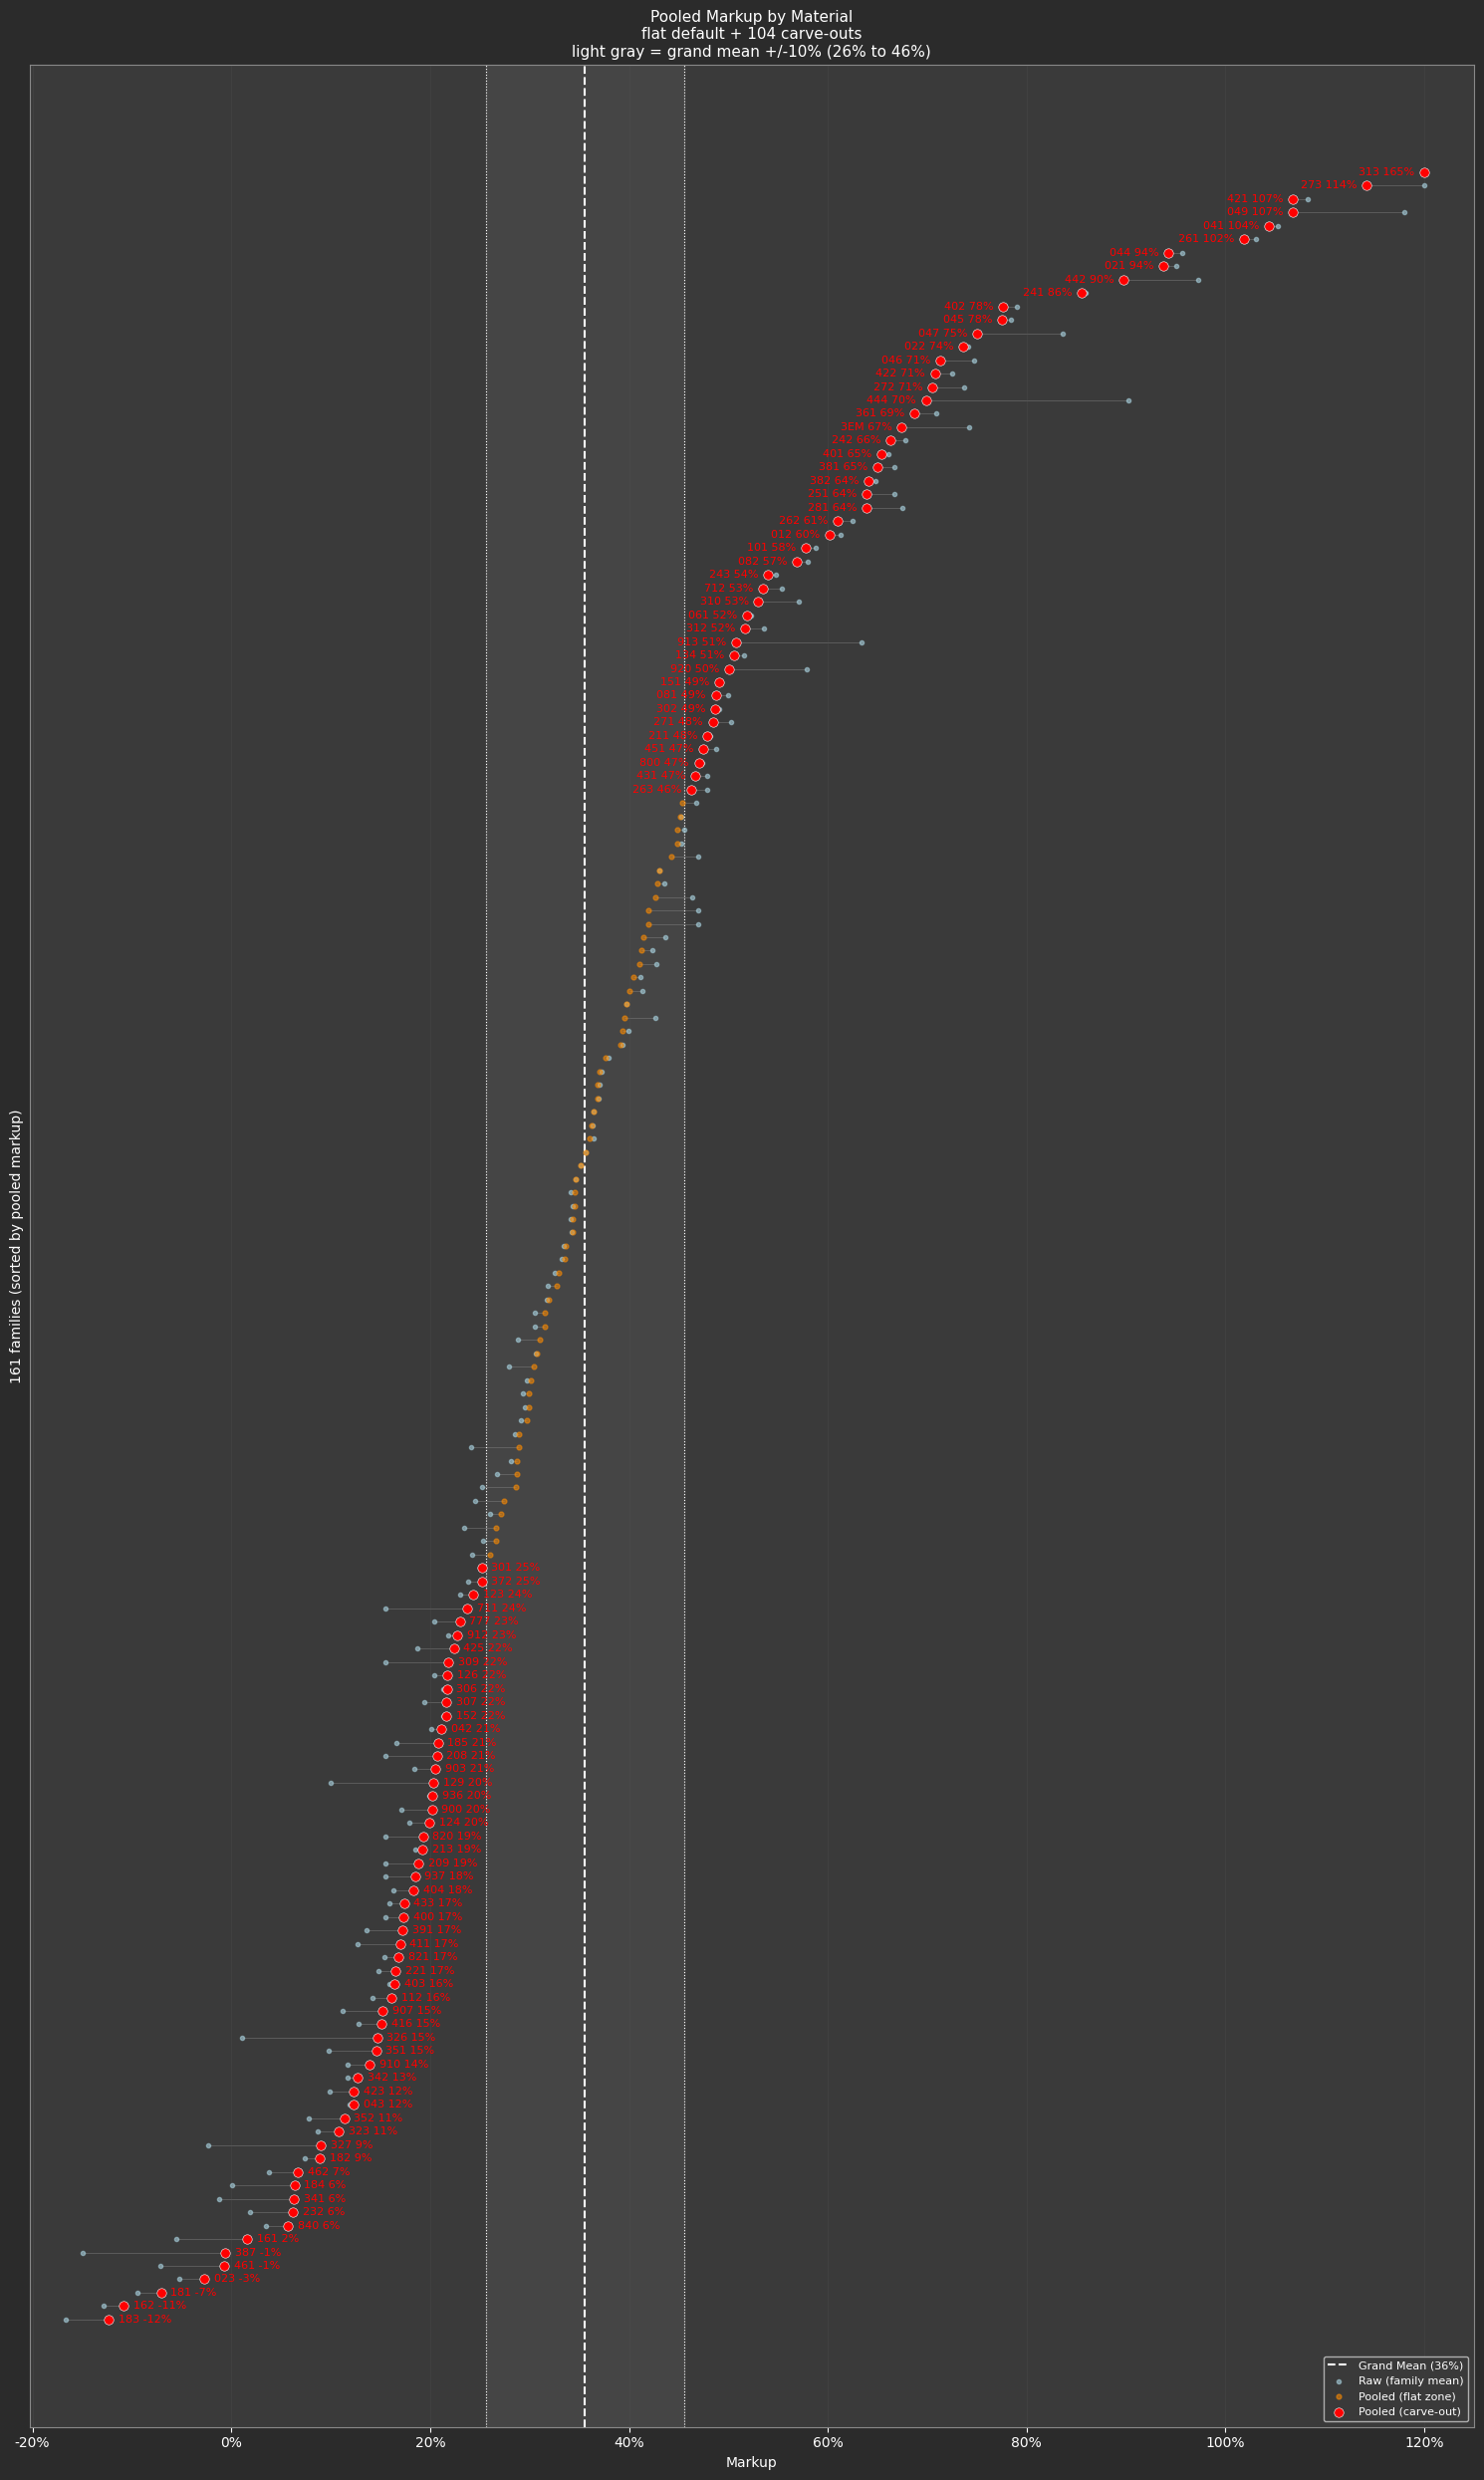

,n,raw_markup,pooled_markup,side
material,,,,
183,13,-17%,-12%,LOW
162,28,-13%,-11%,LOW
181,22,-9%,-7%,LOW
023,19,-5%,-3%,LOW
461,7,-7%,-1%,LOW
387,3,-15%,-1%,LOW
161,6,-6%,2%,LOW
840,18,4%,6%,LOW
232,9,2%,6%,LOW


In [8]:
tol = 0.10
tau = np.sqrt(tau2); gm = np.exp(grand) - 1
band_lo, band_hi = gm - tol, gm + tol
K_SD = (np.log1p(band_hi) - grand) / tau if tau > 0 else float('inf')
af = pooled.sort_values('pooled_markup'); y = np.arange(len(af)); XHI = 1.2
carve = af[(af['pooled_markup'] < band_lo) | (af['pooled_markup'] > band_hi)]
incl = ~af.index.isin(carve.index)

fig, ax = plt.subplots(figsize=(15, 25))
ax.axvspan(band_lo, band_hi, color='white', alpha=.06, zorder=0)
ax.axvline(gm, color='white', lw=1.5, ls='--', label=f'Grand Mean ({gm:.0%})')
for b in (band_lo, band_hi):
    ax.axvline(b, color='white', lw=.8, ls=':')

ax.hlines(y, af['pooled_markup'].clip(upper=XHI), af['raw_markup'].clip(upper=XHI), color='#888', lw=.6, alpha=.5, zorder=1)
ax.scatter(af['raw_markup'].clip(upper=XHI), y, s=9, color='lightblue', alpha=.55, label='Raw (family mean)', zorder=2)
ax.scatter(af['pooled_markup'].clip(upper=XHI)[incl], y[incl], s=12, color='darkorange', alpha=.55, label='Pooled (flat zone)', zorder=3)
ax.scatter(af['pooled_markup'].clip(upper=XHI)[~incl], y[~incl], s=46, color='red', edgecolors='white', linewidths=.4, label='Pooled (carve-out)', zorder=4)
ends = carve.sort_values('pooled_markup')
for code, r in ends.iterrows():
    xx = min(r['pooled_markup'], XHI); side = -1 if r['pooled_markup'] > gm else 1
    ax.annotate(f"{code} {r['pooled_markup']:.0%}", xy=(xx, np.where(af.index == code)[0][0]), xytext=(7 * side, 0), textcoords='offset points', color='red', fontsize=8, va='center', ha='left' if side > 0 else 'right')

ax.set_yticks([]); ax.set_ylabel(f'{len(af)} families (sorted by pooled markup)')
ax.set_xlabel('Markup'); ax.set_xlim(af['pooled_markup'].min() - 0.08, XHI + 0.05)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title(f'Pooled Markup by Material\n'f'flat default + {len(carve)} carve-outs\n'f'light gray = grand mean +/-{tol:.0%} ({band_lo:.0%} to {band_hi:.0%})', fontsize=11)
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=.25, axis='x')
plt.tight_layout(); plt.show()
carve_tbl = carve.copy()
carve_tbl['side'] = np.where(carve_tbl['pooled_markup'] > gm, 'HIGH', 'LOW')
carve_tbl = carve_tbl.sort_values('pooled_markup')[['n', 'raw_markup', 'pooled_markup', 'side']]
carve_tbl.style.format({'raw_markup': '{:.0%}', 'pooled_markup': '{:.0%}'})

Visual and table (`carve_tble`) show that there are 104 families that should have their own unqiue markup. <br>
> Material families do differ enough. <br>
> If each `carve-out` family was given a unique markup, there would be a total = 105 unique markups. <br>

Just looking at the visual, it looks possible to add 2 more markups (w/ their own "within reason" `light gray` ranges) to catch a majority of the families. <br>
However this would still leave ~10+ unique markups, not to mention proper analysis for each. <br>
<br>
Ultimately sustainability is more important and the flat markup is best to remedy the previous lack of standardization by old owners.

## Apply Markup Scenarios
Moving forward w/ a flat markup: <br>
Compute proposed new standard cost (`new_std_...`), dollar difference (`diff_...`), and percent change (`pct_change_...`) for each markup (25%, 30%, 35%, 47%).<br>
47% is the "current markup" (`Markup From Median Ratio = 46.9% (~47%)`) for comparison purposes against proposed markups. <br>

In [9]:
markups = [0.25, 0.30, 0.35, 0.47]
usable_avg = df['avg_cost'] > 0
for m in markups:
    pct = int(m * 100)
    new = np.where(usable_avg, df['avg_cost'] * (1 + m), np.nan)
    df[f'new_std_{pct}'] = new
    df[f'diff_{pct}'] = df[f'new_std_{pct}'] - df['std_cost']
    df[f'pct_change_{pct}'] = np.where(df['std_cost'] > 0, (df[f'new_std_{pct}'] - df['std_cost']) / df['std_cost'], np.nan)
df.head()

,item_no,item_desc_1,item_desc_2,prod_cat,uom,qty_on_hand,qty_allocated,qty_on_ord,reorder_lvl,ord_up_to_lvl,...,pct_change_25,new_std_30,diff_30,pct_change_30,new_std_35,diff_35,pct_change_35,new_std_47,diff_47,pct_change_47
0,010050060096020,BLACK TRESPA,1/2 X 60 X 96,NaN,EA,1,0,0,0,0,...,-0.210433,301.600,-65.69000,-0.178850,313.2000,-54.09000,-0.147268,341.0400,-26.25000,-0.071469
1,010062572096034,TRESPA TOPLAB T.03.40 SILVER,GRAY 5/8X72X96,NaN,SH,3,0,0,0,0,...,-0.149174,640.640,-83.36207,-0.115141,665.2800,-58.72207,-0.081108,724.4160,0.41393,0.000572
2,010075072096034,TRESPA TOPLAB PLUS SILVERGRAY,3/4X72X96 COLOR 0340,NaN,SH,0,0,0,0,0,...,-0.071823,1037.959,-37.30695,-0.034696,1077.8805,2.61455,0.002432,1173.6921,98.42615,0.091537
3,011006024048010,ABS SHEET NATURAL,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,-0.029678,15.665,0.14180,0.009135,16.2675,0.74430,0.047948,17.7135,2.19030,0.141098
4,011006024048110,ABS SHEET BLACK,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,0.256184,20.280,4.75680,0.306432,21.0600,5.53680,0.356679,22.9320,7.40880,0.477273


## Scenario Summary
Table shows for each markup `scenario` how many material items new standard costs moved higher, lower, or were unchanged (`items_...`) <br>
> Difference in $ amounts for mean, median, and total (`..._diff`) shown, as well as median percent change (`median_pct_change`). <br>
> Note that `total_diff` is affected by large items.

In [10]:
scenario_cols = [f'{p}_{int(m*100)}' for m in markups for p in ('diff', 'pct_change')]
valid = valid.join(df[scenario_cols])
rows = []
for m in markups:
    pct = int(m * 100)
    diff = valid[f'diff_{pct}']
    pct_change = valid[f'pct_change_{pct}']
    rows.append({'scenario': f'{pct}% Above Average Cost', 'items_higher': int((diff > 0).sum()), 'items_lower': int((diff < 0).sum()), 'items_unchanged': int((diff == 0).sum()), 'mean_diff': diff.mean(), 'median_diff': diff.median(), 'total_diff': diff.sum(), 'median_pct_change': pct_change.median()})
summary = pd.DataFrame(rows)
summary.style.format({'mean_diff': '${:,.2f}', 'median_diff': '${:,.2f}', 'total_diff': '${:,.2f}', 'median_pct_change': '{:.1%}'})

,scenario,items_higher,items_lower,items_unchanged,mean_diff,median_diff,total_diff,median_pct_change
0,25% Above Average Cost,1157,3052,52,$-31.06,$-1.25,"$-132,346.04",-14.9%
1,30% Above Average Cost,1383,2878,0,$-24.76,$-0.85,"$-105,492.00",-11.5%
2,35% Above Average Cost,1511,2750,0,$-18.46,$-0.55,"$-78,637.96",-8.1%
3,47% Above Average Cost,2427,1834,0,$-3.33,$0.01,"$-14,188.26",0.1%


`25% Above Average Cost` is the only scenario that shows `items_unchanged` isn't 0. <br>
These are material item rows that have `std_cost` already matching the formula (see below):
$$\text{new\_std\_cost} = \text{avg\_cost} \times (1 + markup)$$

`47% Above Average Cost` has `median_pct_change = 0.1%` because `47%` is rounded from `Markup From Median Ratio = 46.9%`

## Current vs. Proposed Standard Costs
Each point is an material item, `Current Standard Cost $` (y) vs `Average Cost $` (x) on log-log axes. <br>
The lines are the markup scenarios, position relative to a line shows whether that markup would raise or lower the item's standard cost.

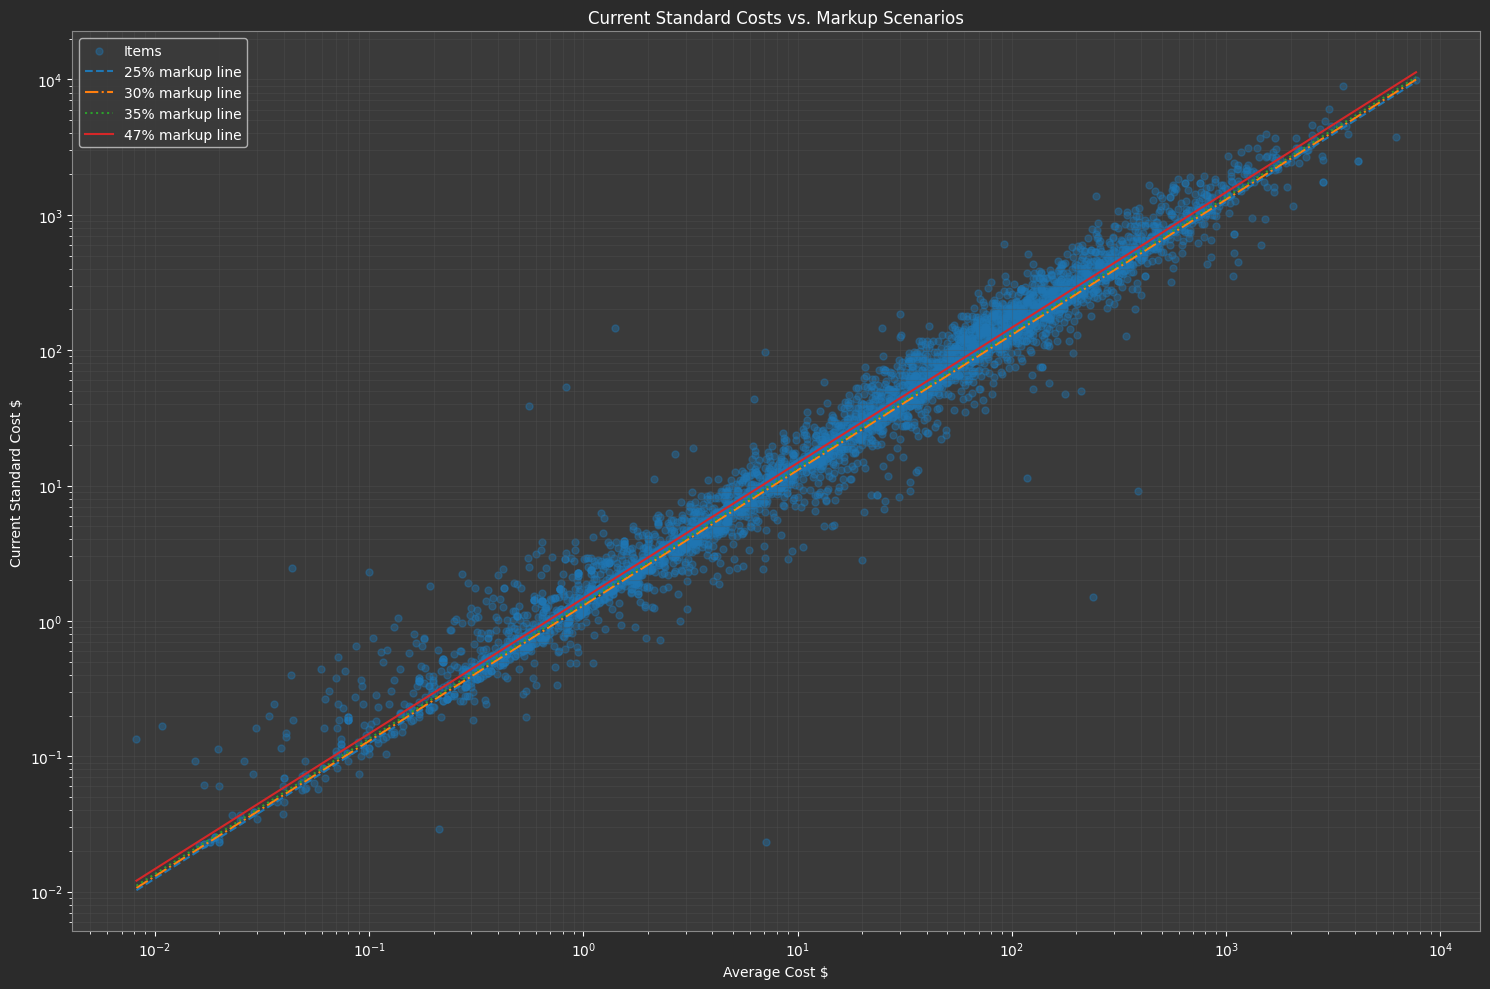

In [11]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.scatter(valid['avg_cost'], valid['std_cost'], alpha=0.4, s=25, label='Items')
x = np.geomspace(valid['avg_cost'].min(), valid['avg_cost'].max(), 100)
for m, style in zip(markups, ['--', '-.', ':', '-']):
    ax.plot(x, x * (1 + m), style, lw=1.5, label=f'{int(m*100)}% markup line')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Average Cost $'); ax.set_ylabel('Current Standard Cost $')
ax.set_title('Current Standard Costs vs. Markup Scenarios')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

Materials above the markup lines have current standard costs higher than the scenario (unrealistic for pricing).<br>
Materials under the lines have lower current standard costs (possible underpricing of final sales).

## Robust Baseline
median +- MAD rule on the log-ratio. <br>
MAD (median absolute deviation) is used instead of standard deviation so the threshold isn't inflated by the outliers and anomalies. Flag anything past `|z| > 3.5`.<br>

In [12]:
med = valid['log_ratio'].median()
mad = (valid['log_ratio'] - med).abs().median()
sigma = 1.4826 * mad
valid['robust_z'] = (valid['log_ratio'] - med) / sigma
valid['flag_mad'] = valid['robust_z'].abs() > 3.5 

print(f'MAD Baseline Center (median log-ratio) = {np.exp(med)-1:.1%}')
print(f'Robust Sigma (log) = {sigma:.3f}')
print(f'Flagged by MAD Rule (|z| > 3.5) = {valid["flag_mad"].sum()} / {len(valid)}')

MAD Baseline Center (median log-ratio) = 46.9%
Robust Sigma (log) = 0.270
Flagged by MAD Rule (|z| > 3.5) = 152 / 4261


## Isolation Forest
Unsupervised anomaly detection as a second opinion on log (`avg_cost`) and `log_ratio`. Overlap and disagreement in flagging are shown.

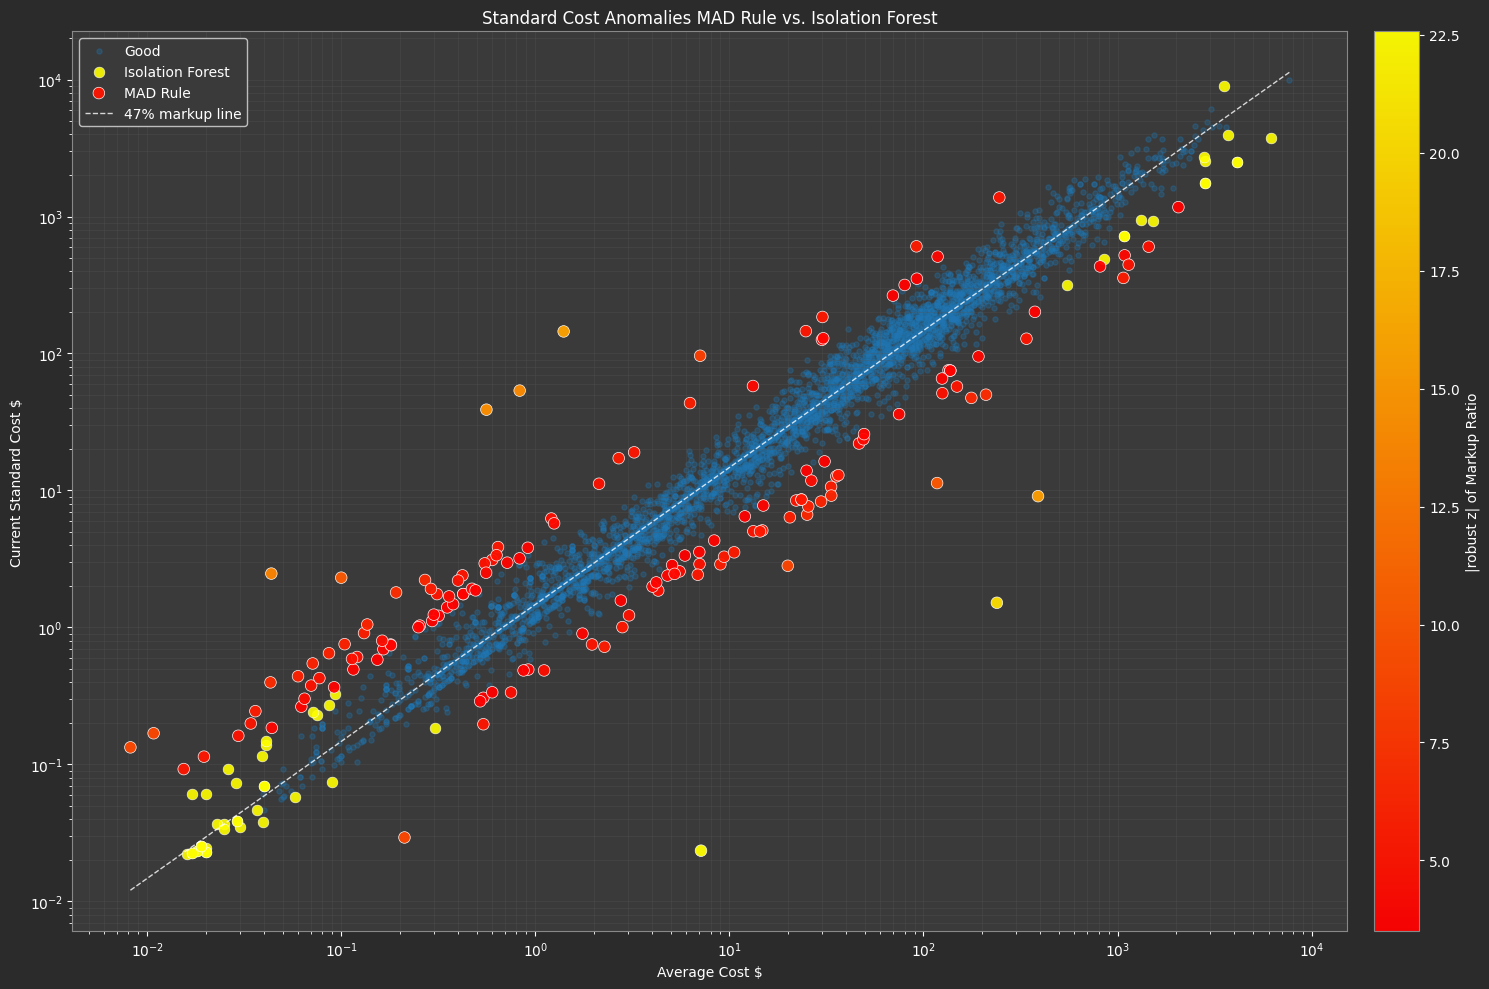

Both = 102 (2.4%)
MAD Only = 50 (1.2%)
Isolation Forest Only = 50 (1.2%)
# of Good Rows = 4059 (95.3%)
Agreement on Flagged = 102 / 152 (67%)


In [13]:
features = pd.DataFrame({'log_avg': np.log(valid['avg_cost']), 'log_ratio': valid['log_ratio']})
iso = IsolationForest(n_estimators=300, contamination='auto', random_state=42)
iso.fit(features)
valid['iso_score'] = -iso.score_samples(features)
n_flag = int(valid['flag_mad'].sum())
cut = valid['iso_score'].nlargest(n_flag).min()
valid['flag_iso'] = valid['iso_score'] >= cut
both = ( valid['flag_mad'] &  valid['flag_iso']).sum()
mad_only = ( valid['flag_mad'] & ~valid['flag_iso']).sum()
iso_only = (~valid['flag_mad'] &  valid['flag_iso']).sum()
neither = (~valid['flag_mad'] & ~valid['flag_iso']).sum()
total = len(valid)

fig, ax = plt.subplots(figsize=(15, 10))
bg = valid[~valid['flag_mad'] & ~valid['flag_iso']]
ax.scatter(bg['avg_cost'], bg['std_cost'], s=14, alpha=0.3, zorder=1, label='Good')
only_iso = valid[valid['flag_iso'] & ~valid['flag_mad']]
ax.scatter(only_iso['avg_cost'], only_iso['std_cost'], c='yellow', s=60, alpha=0.9, edgecolors='white', linewidths=0.4, zorder=2, label='Isolation Forest')
mad_f = valid[valid['flag_mad']]
sc = ax.scatter(mad_f['avg_cost'], mad_f['std_cost'], c=mad_f['robust_z'].abs(), cmap='autumn', s=70, alpha=0.95, edgecolors='white', linewidths=0.5, zorder=3, label='MAD Rule')
xr = np.geomspace(valid['avg_cost'].min(), valid['avg_cost'].max(), 50)
ax.plot(xr, xr * 1.47, '--', color='white', lw=1, alpha=0.8, label='47% markup line')

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('|robust z| of Markup Ratio', color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Average Cost $'); ax.set_ylabel('Current Standard Cost $')
ax.set_title('Standard Cost Anomalies MAD Rule vs. Isolation Forest')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'Both = {both} ({both/total:.1%})')
print(f'MAD Only = {mad_only} ({mad_only/total:.1%})')
print(f'Isolation Forest Only = {iso_only} ({iso_only/total:.1%})')
print(f'# of Good Rows = {neither} ({neither/total:.1%})')
print(f'Agreement on Flagged = {both} / {n_flag} ({both/n_flag:.0%})')

Items exclusive to the isolation forest = extreme costs w/ normal markups. <br>
Decision to be made if this should count as an anomaly.

## Review Table
Sorted by how far the item's markup is from the norm (`Underpriced` or `Overpriced`).

In [14]:
flagged = valid[valid['flag_mad'] | valid['flag_iso']].copy()
flagged['direction'] = np.where(flagged['log_ratio'] > med, 'Overpriced', 'Underpriced')
flagged['method'] = np.select([flagged['flag_mad'] & flagged['flag_iso'], flagged['flag_mad']], ['Both', 'MAD Rule'], default='Isolation Forest')
flagged = flagged.sort_values('robust_z', key=lambda s: s.abs(), ascending=False)
review_cols = ['item_no', 'item_desc_1', 'item_desc_2', 'material', 'avg_cost', 'std_cost', 'ratio', 'robust_z', 'direction', 'method']

print(f'Total Rows Flagged = {len(flagged)}')
flagged[review_cols].style.format({'avg_cost': '${:,.2f}', 'std_cost': '${:,.2f}', 'ratio': '{:.3f}', 'robust_z': '{:+.1f}'})

Total Rows Flagged = 202


,item_no,item_desc_1,item_desc_2,material,avg_cost,std_cost,ratio,robust_z,direction,method
5459,911SJ50032,3M BUMP ON SJ5003 BLACK,nan,911,$7.14,$0.02,0.003,-22.6,Underpriced,Both
5654,936C705,7 X 5 STYLE C SIGN HOLDER,nan,936,$239.00,$1.51,0.006,-20.1,Underpriced,Both
3951,3425000,REXOLITE ROD,5.00 DIA. 1422,342,$1.40,$144.87,103.480,+15.7,Overpriced,Both
1410,1234000250S1525,PULTEX TUBE SQUARE,4 X 1/4 WALL,123,$389.42,$9.08,0.023,-15.3,Underpriced,Both
5445,91062468101308,3M GLUE STICK PURPLE,6 PACKS OF 10,910,$0.56,$38.88,69.424,+14.3,Overpriced,Both
5446,91062468201306,3M GLUE STICK,REPOSITIONABLE 6PK. OF 10,910,$0.83,$53.57,64.463,+14.0,Overpriced,Both
5628,936B85011,8 1/2 X 11 STYLE B SIGN,HOLDER,936,$0.04,$2.47,56.644,+13.5,Overpriced,Both
3305,27310,L/D P/E TUBING,.170 X 1/4 NAT.,273,$0.10,$2.31,23.077,+10.2,Overpriced,Both
5432,91062278604301,3M SCOTCHWELD DP8005,nan,910,$117.60,$11.32,0.096,-10.1,Underpriced,Both
3731,3131,FLEXIBLE VINYL TUBING,.120 X .170 CLEAR,313,$0.01,$0.13,16.232,+8.9,Overpriced,Both


## Review
Above methods are unsupervised, need to review and see if above material items flagged are realistic to standard cost issue.

In [15]:
lab = valid[valid['last_cost'].notna() & (valid['last_cost'] > 0)].copy()
lab['avg_vs_last'] = (lab['avg_cost'] - lab['last_cost']).abs() / lab['last_cost']
lab['label'] = (lab['avg_vs_last'] > 0.50).astype(int)

n_pos = int(lab['label'].sum())
print(f'Number of Positives (avg vs last > 50%) = {n_pos} / {len(lab)} ({lab["label"].mean():.1%})')

Number of Positives (avg vs last > 50%) = 19 / 4256 (0.4%)


Label of `|avg_cost - last_cost| / last_cost > 0.50` is not independent from the `MAD Rule` and `Isolation Forest` scores built on `log(std_cost / avg_cost)`. <br>
> If `avg_cost` data is obsolete or stale it affects both the above and log ratio. <br>
> This makes it partly mechanical rather than true detection. `19 / 4256` positives makes the cross validation very noisy. <br>

This shows that the A/B test `MAD Rule` or `Isolation Forest` does not produce a clear winner but both should be considered complementary. <br>
`19 / 4256` positives is for context, not a validated score.

### Precision-Recall w/ Precision@K
Precision and Recall curves show the full trade-off. Precision@K table checks how many rows are problems based on top K.

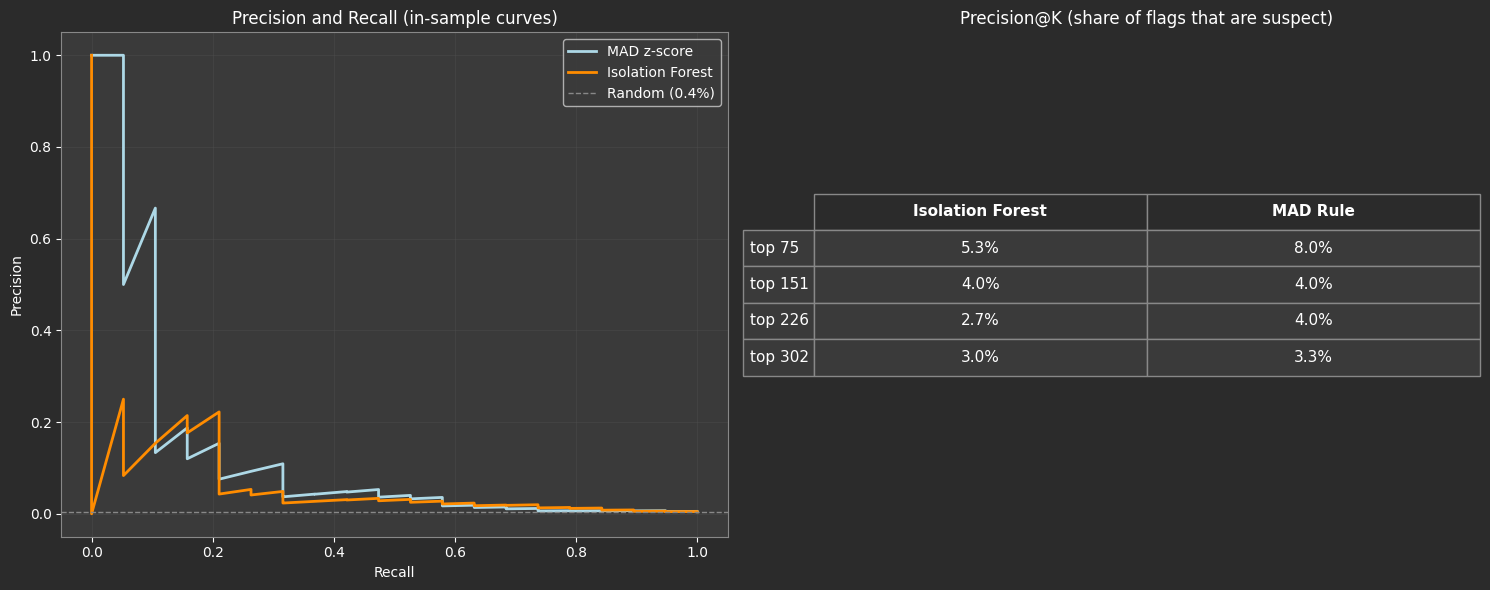

method,Isolation Forest,MAD Rule
K,,
75,5.3%,8.0%
151,4.0%,4.0%
226,2.7%,4.0%
302,3.0%,3.3%


In [16]:
y = lab['label'].values
log_ratio_lab = lab['log_ratio'].values
X = np.c_[np.log(lab['avg_cost']), log_ratio_lab]

iso_full = IsolationForest(n_estimators=300, contamination='auto', random_state=42).fit(X)
iso_full_score = -iso_full.score_samples(X)

med_l = np.median(log_ratio_lab)
sigma_l = 1.4826 * np.median(np.abs(log_ratio_lab - med_l))
mad_score = np.abs((log_ratio_lab - med_l) / sigma_l)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for score, name, col in [(mad_score, 'MAD z-score', 'lightblue'), (iso_full_score, 'Isolation Forest', 'darkorange')]:
    p, r, _ = precision_recall_curve(y, score)
    ax[0].plot(r, p, lw=2, label=name, color=col)
ax[0].axhline(y.mean(), color='#888', ls='--', lw=1, label=f'Random ({y.mean():.1%})')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Precision and Recall (in-sample curves)'); ax[0].legend(); ax[0].grid(alpha=0.3)

K = int((mad_score > 3.5).sum())
ks = sorted({int(K*0.5), K, int(K*1.5), 2*K})
rows = []
for k in ks:
    k = min(max(k, 1), len(y))
    for score, name in [(mad_score, 'MAD Rule'), (iso_full_score, 'Isolation Forest')]:
        top = np.argsort(score)[::-1][:k]
        rows.append({'K': k, 'method': name, 'precision@K': y[top].mean(), 'hits': int(y[top].sum())})

patk = pd.DataFrame(rows).pivot(index='K', columns='method', values='precision@K')
ax[1].axis('off')
tbl = ax[1].table(cellText=[[f'{v:.1%}' for v in r] for r in patk.values], rowLabels=[f'top {k}' for k in patk.index], colLabels=patk.columns, loc='center', cellLoc='center')
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#888')
    if r == 0:
        cell.set_facecolor('#2b2b2b'); cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#3a3a3a'); cell.set_text_props(color='white')
tbl.scale(1, 2); tbl.auto_set_font_size(False); tbl.set_fontsize(11)
ax[1].set_title('Precision@K (share of flags that are suspect)')
plt.tight_layout(); plt.show()
patk.style.format('{:.1%}')

Neither method beats out the other and both are complementary as seen above. <br>
> `MAD Rule` could be used as primary detection. <br>
> `Isolation Forest` could be used as secondary detection for extreme cost items w/ normal markups.

## Sanity Check if Average Cost is Current
Check `avg_cost` against `last_cost`. Rows where they diverge by more than 20% are listed for review. <br>
`0.20` will provide a larger range than the `0.50` in the above review as a safety to the manual check.

In [17]:
chk = valid[valid['last_cost'].notna() & (valid['last_cost'] > 0)].copy()
chk['avg_vs_last'] = (chk['avg_cost'] - chk['last_cost']) / chk['last_cost']
stale = (chk['avg_vs_last'].abs() > 0.20)
stale_rows = chk[stale].sort_values('avg_vs_last', key=abs, ascending=False)
print(f'Rows Where Difference >20% = {stale.sum()} / {len(chk)} ({stale.mean():.1%})')
stale_rows[['item_no','item_desc_1','item_desc_2','avg_cost', 'last_cost', 'avg_vs_last']].style.format({'avg_cost': '${:,.2f}', 'last_cost': '${:,.2f}', 'avg_vs_last': '{:+.1%}'})

Rows Where Difference >20% = 89 / 4256 (2.1%)


,item_no,item_desc_1,item_desc_2,avg_cost,last_cost,avg_vs_last
5459,911SJ50032,3M BUMP ON SJ5003 BLACK,nan,$7.14,$0.02,+39582.8%
2491,21301250010000,NYLON BUSHING STOCK,11/4OD X .125WALL X 1'ID,$11.11,$3.96,+180.4%
2966,24270000000,POLY CARBONATE ROD,7' DIA. NAT.,$283.55,$102.97,+175.4%
619,04304500003750,CAST ACRYLIC TUBING,4 1/2 OD X 3/8 WALL,$80.44,$35.98,+123.6%
3951,3425000,REXOLITE ROD,5.00 DIA. 1422,$1.40,$116.14,-98.8%
4451,4020050000,UHMW ROD 1/2 NAT,nan,$1.36,$35.94,-96.2%
874,046RS250500,ACRYLIC RECTANGULAR STRIP,.250 X 500,$0.04,$0.27,-84.0%
3600,3060125011,PVC PIPE 1 1/4',SCH 40 WHITE,$0.06,$0.30,-80.0%
1890,15313751250100,IND LAM G-10 TUBE,"1 3/8"" OD X 1 1/4"" ID",$3.23,$12.92,-75.0%
1688,151062536048011,IND. LAM SHEET,.625 X 36 X 48 BLACK PAPER,$24.77,$99.10,-75.0%


These items may require having their `avg_cost` updated or `last_cost` validated.